# Fixed Income: Investment Grade and High Yield

Compare LQD (Investment Grade corporate bonds), HYG (High Yield corporate bonds) and SPY (US equities): historical return, downside risk and equity co-movement.

This module extends the cross-asset project using its shared risk functions and a saved price snapshot.


In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

from src.data import load_prices
from src.metrics import comparison_metrics, wealth_and_drawdown
from src.fixed_income import stress_period_comparison

ROOT = Path.cwd()
SNAPSHOT = ROOT / "data/fixed_income_prices_snapshot.csv"
TABLES = ROOT / "outputs/fixed_income/tables"
FIGURES = ROOT / "outputs/fixed_income/figures"
for folder in (TABLES, FIGURES):
    folder.mkdir(parents=True, exist_ok=True)
TICKERS = ["LQD", "HYG", "SPY"]
TRADING_DAYS = 252
plt.style.use("seaborn-v0_8-whitegrid")
COLOURS = ["#245B83", "#C36A2D", "#666666"]

## Data and sample

Yahoo Finance adjusted Close, downloaded with `yfinance` (`auto_adjust=True`) on 23 September 2026. The common sample is **2 January 2015–31 December 2025**: 2,766 prices and 2,765 daily returns per ETF. Adjustments provide a USD total-return proxy, not official fund NAV performance; dividends are not added again.

The run stops on missing prices; no filling is used. Dates follow the saved vendor calendar, without an independent exchange-calendar audit. Full provenance is in [data metadata](data/fixed_income_metadata.json). This sample differs from the main notebook.


In [2]:
metadata = json.loads((ROOT / "data/fixed_income_metadata.json").read_text())
assert hashlib.sha256(SNAPSHOT.read_bytes()).hexdigest() == metadata["snapshot_sha256"], "Snapshot changed: review provenance and commentary."
prices = load_prices(SNAPSHOT, TICKERS)
if prices.isna().any().any():
    raise ValueError("Missing ETF prices: investigate before calculating returns.")
returns = prices.pct_change(fill_method=None).iloc[1:]
if not np.isfinite(returns.to_numpy()).all():
    raise ValueError("Invalid returns.")
assert len(prices) == metadata["price_observations"]
assert len(returns) == metadata["return_observations"]
assert str(prices.index[0].date()) == metadata["first_price_date"]
assert str(prices.index[-1].date()) == metadata["last_price_date"]
print(f"Source: {metadata['source']}; downloaded {metadata['downloaded_at_utc']}")
print(f"Price dates: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"{len(prices):,} prices / {len(returns):,} daily returns per ETF; missing prices: 0")
display(prices.head())

Source: Yahoo Finance via yfinance; downloaded 2026-09-23T19:07:05.242692+00:00
Price dates: 2015-01-02 to 2025-12-31
2,766 prices / 2,765 daily returns per ETF; missing prices: 0


,LQD,HYG,SPY
Date,,,
2015-01-02,79.445412,48.073135,169.267426
2015-01-05,79.770218,47.627789,166.210632
2015-01-06,80.095139,47.445347,164.645065
2015-01-07,80.201157,47.740448,166.696732
2015-01-08,79.942635,48.099934,169.654785


## Return and risk

CAGR uses elapsed calendar years; volatility uses daily sample standard deviation × √252. Maximum drawdown is measured from each ETF's running peak, including initial capital. Historical VaR is minus the 5th/1st percentile of daily returns: a one-day loss threshold, not a worst-case loss. Calculations use `src.metrics`.

HYG earned more than LQD in this sample, but did not have higher volatility or a deeper maximum drawdown. Its 99% Historical VaR was slightly higher.


In [3]:
metric_columns = ["Cumulative return", "Annualised return", "Annualised volatility",
                  "Maximum drawdown", "Historical VaR 95%", "Historical VaR 99%"]
comparison = comparison_metrics(returns, prices.index[0], trading_days=TRADING_DAYS)[metric_columns]
comparison.index.name = "Ticker"
comparison.to_csv(TABLES / "performance_comparison.csv")
display(comparison.style.format("{:.2%}").set_caption("Return and Risk, 2015–2025"))

,Cumulative return,Annualised return,Annualised volatility,Maximum drawdown,Historical VaR 95%,Historical VaR 99%
Ticker,,,,,,
LQD,34.47%,2.73%,8.45%,-24.95%,0.75%,1.35%
HYG,61.16%,4.44%,8.31%,-22.03%,0.70%,1.43%
SPY,299.74%,13.43%,17.79%,-33.72%,1.67%,3.22%


## Cumulative performance

Compare growth from a common starting value of 100. All paths include the first price date as initial capital.


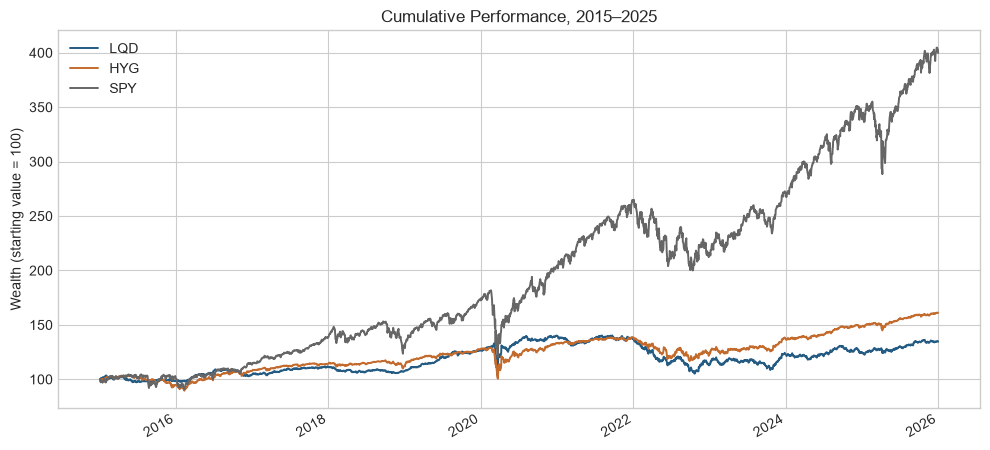

In [4]:
wealth = pd.DataFrame(index=returns.index)
drawdowns = pd.DataFrame(index=returns.index)
for ticker in TICKERS:
    wealth[ticker], drawdowns[ticker] = wealth_and_drawdown(returns[ticker])
initial = pd.DataFrame(1.0, index=prices.index[:1], columns=TICKERS)
wealth = pd.concat([initial, wealth]) * 100
drawdowns = pd.concat([initial * 0, drawdowns])
wealth.to_csv(TABLES / "cumulative_wealth.csv")
drawdowns.to_csv(TABLES / "drawdowns.csv")

fig, ax = plt.subplots(figsize=(10, 4.6))
wealth.plot(ax=ax, color=COLOURS, linewidth=1.4)
ax.set(title="Cumulative Performance, 2015–2025", ylabel="Wealth (starting value = 100)", xlabel="")
fig.tight_layout()
fig.savefig(FIGURES / "cumulative_performance.png", dpi=160)
plt.show()

## Drawdowns

Compare the depth and duration of declines from each ETF's own prior peak. Separate panels share the same scale; daily data are not smoothed.


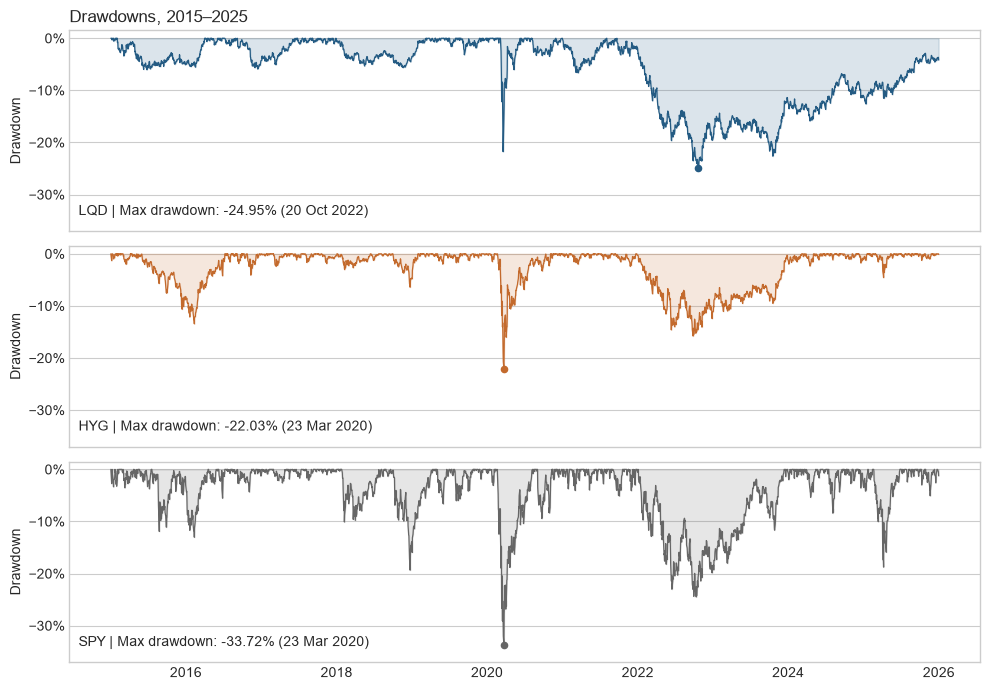

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, ticker, colour in zip(axes, TICKERS, COLOURS):
    series = drawdowns[ticker]
    ax.plot(series.index, series, color=colour, linewidth=0.9)
    ax.fill_between(series.index, series, 0, color=colour, alpha=0.16)
    trough_date = series.idxmin()
    trough = series.loc[trough_date]
    ax.scatter([trough_date], [trough], color=colour, s=20, zorder=3)
    ax.text(0.01, 0.08, f"{ticker} | Max drawdown: {trough:.2%} ({trough_date:%d %b %Y})",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
    ax.set_ylim(-0.37, 0.015)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set_ylabel("Drawdown")
    ax.grid(axis="x", visible=False)
axes[0].set_title("Drawdowns, 2015–2025", loc="left")
fig.tight_layout()
fig.savefig(FIGURES / "drawdown_comparison.png", dpi=160)
plt.show()


## Daily return correlations

HYG's correlation with SPY was 0.768, compared with 0.270 for LQD. Correlation describes co-movement, not the size or cause of a response.


In [6]:
correlation = returns.corr()
correlation.to_csv(TABLES / "correlation_matrix.csv")
display(correlation.style.format("{:.3f}").set_caption("Pearson correlation of daily returns"))

,LQD,HYG,SPY
LQD,1.000,0.517,0.270
HYG,0.517,1.000,0.768
SPY,0.270,0.768,1.000


## Performance in selected stress periods

These are historical case studies, not model-defined market regimes. The main comparison is between the COVID sell-off and 2022; Q4 2018 provides a supplementary example.

| Period | Return dates | Context |
|---|---|---|
| COVID sell-off | 20 Feb–23 Mar 2020 | Pandemic disruption and liquidity pressure; excludes the rebound |
| 2022 repricing | 1 Jan–30 Dec 2022 | Inflation and rising rates; includes intra-year recoveries |
| Q4 2018 | 1 Oct–31 Dec 2018 | Growth concerns and an equity sell-off |

Each period includes the return from the preceding close. Drawdown resets at that close; period returns are not annualised. Windows differ in length and were selected retrospectively.

HYG lost more during the COVID window (−21.90% versus −12.30% for LQD), while LQD lost more in 2022 (−17.92% versus −10.98%). This contrast motivates checking both rate and spread exposure; it does not isolate either effect.

Historical context: [Federal Reserve, COVID](https://www.federalreserve.gov/econres/notes/feds-notes/the-corporate-bond-market-crises-and-the-government-response-20201007.html), [2022](https://www.federalreserve.gov/publications/2022-ar-monetary-policy.htm), [Q4 2018](https://www.federalreserve.gov/monetarypolicy/2019-02-mpr-part1.htm).


In [7]:
periods = {
    "Q4 2018": ("2018-10-01", "2018-12-31"),
    "COVID sell-off": ("2020-02-20", "2020-03-23"),
    "2022 repricing": ("2022-01-01", "2022-12-30"),
}
stress = stress_period_comparison(returns, periods, prices.index[0])
stress.to_csv(TABLES / "stress_period_comparison.csv")
display_order = ["COVID sell-off", "2022 repricing", "Q4 2018"]
display(stress.loc[display_order, ["Observations", "Cumulative return", "Maximum drawdown", "Correlation with SPY"]]
        .style.format({"Observations": "{:.0f}", "Cumulative return": "{:.2%}",
                       "Maximum drawdown": "{:.2%}", "Correlation with SPY": "{:.3f}"})
        .set_caption("Selected Stress Periods — Q4 2018 is supplementary"))
# Exact boundary dates remain in the saved CSV for inspection.


## Validation

Check compounding, annualisation, drawdown, VaR signs and stress boundaries independently; reconcile saved tables with the calculations.


In [8]:
np.testing.assert_allclose(wealth.iloc[-1] / 100, prices.iloc[-1] / prices.iloc[0])
np.testing.assert_allclose(comparison["Cumulative return"], prices.iloc[-1] / prices.iloc[0] - 1)
years = (prices.index[-1] - prices.index[0]).days / 365.25
np.testing.assert_allclose(comparison["Annualised return"], (prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1)
np.testing.assert_allclose(comparison["Annualised volatility"], returns.std(ddof=1) * np.sqrt(252))
np.testing.assert_allclose(drawdowns, prices / prices.cummax() - 1, atol=1e-12)
np.testing.assert_allclose(comparison["Maximum drawdown"], drawdowns.min())
for confidence, column in [(0.95, "Historical VaR 95%"), (0.99, "Historical VaR 99%")]:
    np.testing.assert_allclose(comparison[column], -returns.quantile(1-confidence, interpolation="linear"))
assert (comparison["Historical VaR 99%"] >= comparison["Historical VaR 95%"]).all()
np.testing.assert_allclose(correlation, np.corrcoef(returns.to_numpy().T))
for (_, ticker), row in stress.iterrows():
    expected = prices.loc[row["Last return date"], ticker] / prices.loc[row["Base price date"], ticker] - 1
    np.testing.assert_allclose(row["Cumulative return"], expected, atol=1e-12)
for name, table in [("performance_comparison", comparison), ("correlation_matrix", correlation),
                    ("cumulative_wealth", wealth), ("drawdowns", drawdowns)]:
    saved = pd.read_csv(TABLES / f"{name}.csv", index_col=0)
    np.testing.assert_allclose(saved.to_numpy(), table.to_numpy(), atol=1e-12)
saved_stress = pd.read_csv(TABLES / "stress_period_comparison.csv", index_col=[0, 1])
pd.testing.assert_frame_equal(saved_stress, stress, check_dtype=False, atol=1e-12)
print("All sample, compounding, volatility, drawdown, VaR, correlation and saved-table checks passed.")

All sample, compounding, volatility, drawdown, VaR, correlation and saved-table checks passed.


## Conclusions

- HYG had higher historical returns than LQD, but risk rankings differed across volatility, drawdown and tail losses.
- HYG showed stronger equity co-movement. LQD offers higher-quality corporate exposure, but is still vulnerable to rising yields; neither is automatic protection against equity losses.
- ETF returns combine interest-rate and credit-spread risk. Duration, holdings, sectors and credit quality differ; these results do not isolate credit risk or establish relative value. They are not issuer-level analysis or a forecast. Fund expenses are reflected in prices; investor dealing costs and taxes are excluded.

See the [one-page summary](FIXED_INCOME_SUMMARY.md) for the main findings.
